# Classical baselines — RadioML 2016.10A

This notebook builds the first classical machine-learning baseline for
automatic modulation classification.

Objectives:

- Extract interpretable features from I/Q samples.
- Establish a DummyClassifier baseline.
- Train a Logistic Regression classifier.
- Compare performance using accuracy and macro-F1.
- Study whether increasing the training set improves the linear baseline.

The test set is not used in this notebook.

In [1]:
## 1. Setup and data loading
from pathlib import Path
import pickle

import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from time import perf_counter
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

In [2]:
DATA_PATH = Path("../data/raw/RML2016.10a/RML2016.10a_dict.pkl")
PROCESSED_DIR = Path("../data/processed")

with open(DATA_PATH, "rb") as f:
    radioml = pickle.load(f, encoding="latin1")

train_metadata = pd.read_csv(
    PROCESSED_DIR / "train_metadata.csv"
)

validation_metadata = pd.read_csv(
    PROCESSED_DIR / "validation_metadata.csv"
)

print("RadioML combinations:", len(radioml))
print("Train:", train_metadata.shape)
print("Validation:", validation_metadata.shape)

RadioML combinations: 220
Train: (154000, 4)
Validation: (33000, 4)


## 2. Basic feature engineering

Each RadioML sample has shape `(2, 128)`, containing the I and Q
components of the received signal.

We transform each signal into 12 interpretable time-domain features
describing I/Q statistics, magnitude, power, PAPR and phase variation.

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

from rfml.features import (
    extract_basic_features,
    extract_features,
    build_feature_table,
)

In [4]:
sample = radioml[("QPSK", 18)][0]

basic = extract_features(
    sample,
    feature_set="basic"
)

temporal = extract_features(
    sample,
    feature_set="temporal"
)

full = extract_features(
    sample,
    feature_set="full"
)

print("Basic:", len(basic))
print("Temporal:", len(temporal))
print("Full:", len(full))

assert all(np.isfinite(list(basic.values())))
assert all(np.isfinite(list(temporal.values())))
assert all(np.isfinite(list(full.values())))

print("✅ All feature sets are valid.")

Basic: 11
Temporal: 22
Full: 28
✅ All feature sets are valid.


## 3. Initial baseline on a small subset

We first use 5 samples from every `(modulation, SNR)` combination.

With 220 strata, this gives:

- 1,100 training samples
- 1,100 validation samples

This experiment verifies that the complete ML pipeline works before
scaling to larger subsets.

In [5]:
train_tiny = (
    train_metadata
    .groupby(["modulation", "snr"], group_keys=False)
    .sample(n=5, random_state=42)
    .reset_index(drop=True)
)

validation_tiny = (
    validation_metadata
    .groupby(["modulation", "snr"], group_keys=False)
    .sample(n=5, random_state=42)
    .reset_index(drop=True)
)

train_features_tiny = build_feature_table(
    radioml,
    train_tiny
)

validation_features_tiny = build_feature_table(
    radioml,
    validation_tiny
)

In [6]:
metadata_columns = [
    "sample_id",
    "modulation",
    "snr",
]

feature_columns = [
    column
    for column in train_features_tiny.columns
    if column not in metadata_columns
]

X_train_tiny = train_features_tiny[feature_columns]
y_train_tiny = train_features_tiny["modulation"]

X_validation_tiny = validation_features_tiny[feature_columns]
y_validation_tiny = validation_features_tiny["modulation"]

print("X_train:", X_train_tiny.shape)
print("X_validation:", X_validation_tiny.shape)
print("Features:", len(feature_columns))

X_train: (1100, 11)
X_validation: (1100, 11)
Features: 11


In [7]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train_tiny,
    y_train_tiny
)

dummy_predictions = dummy_model.predict(
    X_validation_tiny
)

dummy_accuracy = accuracy_score(
    y_validation_tiny,
    dummy_predictions
)

dummy_f1 = f1_score(
    y_validation_tiny,
    dummy_predictions,
    average="macro"
)


logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42,
        ),
    ),
])

logistic_model.fit(
    X_train_tiny,
    y_train_tiny
)

logistic_predictions = logistic_model.predict(
    X_validation_tiny
)

logistic_accuracy = accuracy_score(
    y_validation_tiny,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_validation_tiny,
    logistic_predictions,
    average="macro"
)

In [8]:
baseline_results = pd.DataFrame([
    {
        "model": "DummyClassifier",
        "accuracy": dummy_accuracy,
        "macro_f1": dummy_f1,
    },
    {
        "model": "LogisticRegression",
        "accuracy": logistic_accuracy,
        "macro_f1": logistic_f1,
    },
])

baseline_results

,model,accuracy,macro_f1
0,DummyClassifier,0.090909,0.015152
1,LogisticRegression,0.410000,0.396127


## 4. Scaling experiment

To determine whether the linear baseline is mainly limited by the
amount of training data, the training subset is increased from
1,100 to 11,000 samples.

The feature set and Logistic Regression model remain unchanged.

Both models are evaluated on the same 4,400-sample validation subset
to make the comparison fair.

In [9]:
train_medium = (
    train_metadata
    .groupby(["modulation", "snr"], group_keys=False)
    .sample(n=50, random_state=42)
    .reset_index(drop=True)
)

validation_medium = (
    validation_metadata
    .groupby(["modulation", "snr"], group_keys=False)
    .sample(n=20, random_state=42)
    .reset_index(drop=True)
)

train_features_medium = build_feature_table(
    radioml,
    train_medium
)

validation_features_medium = build_feature_table(
    radioml,
    validation_medium
)

X_train_medium = train_features_medium[feature_columns]
y_train_medium = train_features_medium["modulation"]

X_validation_medium = validation_features_medium[feature_columns]
y_validation_medium = validation_features_medium["modulation"]

print("Train:", X_train_medium.shape)
print("Validation:", X_validation_medium.shape)

Train: (11000, 11)
Validation: (4400, 11)


In [10]:
tiny_predictions_fixed_val = logistic_model.predict(
    X_validation_medium
)

tiny_accuracy_fixed_val = accuracy_score(
    y_validation_medium,
    tiny_predictions_fixed_val
)

tiny_f1_fixed_val = f1_score(
    y_validation_medium,
    tiny_predictions_fixed_val,
    average="macro"
)

In [11]:
logistic_model_medium = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42,
        ),
    ),
])

logistic_model_medium.fit(
    X_train_medium,
    y_train_medium
)

medium_predictions = logistic_model_medium.predict(
    X_validation_medium
)

medium_accuracy = accuracy_score(
    y_validation_medium,
    medium_predictions
)

medium_f1 = f1_score(
    y_validation_medium,
    medium_predictions,
    average="macro"
)

In [12]:
scaling_results = pd.DataFrame([
    {
        "train_samples": 1100,
        "accuracy": tiny_accuracy_fixed_val,
        "macro_f1": tiny_f1_fixed_val,
    },
    {
        "train_samples": 11000,
        "accuracy": medium_accuracy,
        "macro_f1": medium_f1,
    },
])

scaling_results

,train_samples,accuracy,macro_f1
0,1100,0.402273,0.391777
1,11000,0.411818,0.395783


## 5. Random Forest baseline

Random Forest is evaluated using the same 11,000 training samples,
4,400 validation samples and 12 engineered features used for the
medium Logistic Regression experiment.

This provides a direct comparison between a linear classifier and
a non-linear ensemble model.

In [13]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start = perf_counter()

random_forest_model.fit(
    X_train_medium,
    y_train_medium
)

rf_training_time = perf_counter() - start

print(f"Training time: {rf_training_time:.2f} seconds")

Training time: 1.49 seconds


In [14]:
start = perf_counter()

rf_predictions = random_forest_model.predict(
    X_validation_medium
)

rf_inference_time = perf_counter() - start

rf_accuracy = accuracy_score(
    y_validation_medium,
    rf_predictions
)

rf_f1 = f1_score(
    y_validation_medium,
    rf_predictions,
    average="macro"
)

print("Random Forest")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Macro-F1: {rf_f1:.4f}")
print(f"Inference time: {rf_inference_time:.4f} seconds")

Random Forest
Accuracy: 0.4675
Macro-F1: 0.4763
Inference time: 0.1499 seconds


In [15]:
model_results = pd.DataFrame([
    {
        "model": "DummyClassifier",
        "accuracy": dummy_accuracy,
        "macro_f1": dummy_f1,
    },
    {
        "model": "LogisticRegression",
        "accuracy": medium_accuracy,
        "macro_f1": medium_f1,
    },
    {
        "model": "RandomForest",
        "accuracy": rf_accuracy,
        "macro_f1": rf_f1,
    },
])

model_results

,model,accuracy,macro_f1
0,DummyClassifier,0.090909,0.015152
1,LogisticRegression,0.411818,0.395783
2,RandomForest,0.467500,0.476339


In [16]:
dummy_predictions_medium = dummy_model.predict(
    X_validation_medium
)

dummy_accuracy_medium = accuracy_score(
    y_validation_medium,
    dummy_predictions_medium
)

dummy_f1_medium = f1_score(
    y_validation_medium,
    dummy_predictions_medium,
    average="macro"
)

In [17]:
model_results = pd.DataFrame([
    {
        "model": "DummyClassifier",
        "accuracy": dummy_accuracy_medium,
        "macro_f1": dummy_f1_medium,
    },
    {
        "model": "LogisticRegression",
        "accuracy": medium_accuracy,
        "macro_f1": medium_f1,
    },
    {
        "model": "RandomForest",
        "accuracy": rf_accuracy,
        "macro_f1": rf_f1,
    },
])

model_results

,model,accuracy,macro_f1
0,DummyClassifier,0.090909,0.015152
1,LogisticRegression,0.411818,0.395783
2,RandomForest,0.467500,0.476339


## 6. HistGradientBoosting baseline

A HistGradientBoosting classifier is evaluated using the same
11,000 training samples, 4,400 validation samples and 12 engineered
features.

This provides a third classical model based on sequential boosting,
complementing the linear Logistic Regression and bagging-based
Random Forest approaches.

In [18]:
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    max_leaf_nodes=31,
    random_state=42
)

start = perf_counter()

hgb_model.fit(
    X_train_medium,
    y_train_medium
)

hgb_training_time = perf_counter() - start

print(f"Training time: {hgb_training_time:.2f} seconds")

Training time: 14.97 seconds


In [19]:
start = perf_counter()

hgb_predictions = hgb_model.predict(
    X_validation_medium
)

hgb_inference_time = perf_counter() - start

hgb_accuracy = accuracy_score(
    y_validation_medium,
    hgb_predictions
)

hgb_f1 = f1_score(
    y_validation_medium,
    hgb_predictions,
    average="macro"
)

print("HistGradientBoosting")
print(f"Accuracy: {hgb_accuracy:.4f}")
print(f"Macro-F1: {hgb_f1:.4f}")
print(f"Inference time: {hgb_inference_time:.4f} seconds")

HistGradientBoosting
Accuracy: 0.4561
Macro-F1: 0.4626
Inference time: 0.1919 seconds


In [20]:
model_results = pd.DataFrame([
    {
        "model": "DummyClassifier",
        "accuracy": dummy_accuracy_medium,
        "macro_f1": dummy_f1_medium,
    },
    {
        "model": "LogisticRegression",
        "accuracy": medium_accuracy,
        "macro_f1": medium_f1,
    },
    {
        "model": "RandomForest",
        "accuracy": rf_accuracy,
        "macro_f1": rf_f1,
    },
    {
        "model": "HistGradientBoosting",
        "accuracy": hgb_accuracy,
        "macro_f1": hgb_f1,
    },
])

model_results.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

,model,accuracy,macro_f1
0,RandomForest,0.467500,0.476339
1,HistGradientBoosting,0.456136,0.462637
2,LogisticRegression,0.411818,0.395783
3,DummyClassifier,0.090909,0.015152


## 7. Feature analysis

The current Random Forest baseline is used to inspect which engineered
features contribute most to validation performance.

Permutation importance is preferred over the model's impurity-based
feature importance because it directly measures the drop in predictive
performance when each feature is disrupted.

In [21]:
permutation_results = permutation_importance(
    random_forest_model,
    X_validation_medium,
    y_validation_medium,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [22]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": permutation_results.importances_mean,
    "importance_std": permutation_results.importances_std,
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

importance_df

,feature,importance_mean,importance_std
0,phase_diff_std,0.131754,0.003336
1,q_std,0.072637,0.003250
2,i_std,0.068665,0.002148
3,magnitude_std,0.046551,0.003943
4,rms,0.043717,0.003361
5,q_mean,0.027370,0.002906
6,phase_diff_mean,0.026070,0.001929
7,papr,0.020971,0.003797
8,i_mean,0.017771,0.002678
9,magnitude_max,0.011895,0.002764


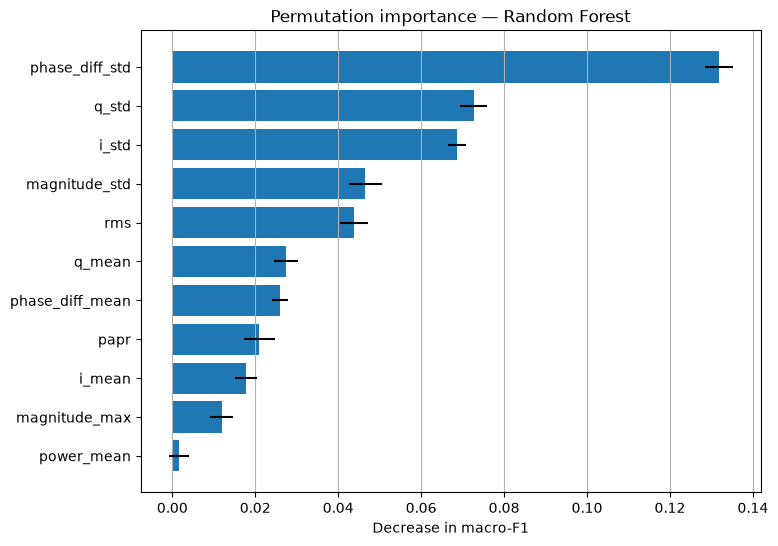

In [23]:
import matplotlib.pyplot as plt

plot_df = importance_df.sort_values(
    "importance_mean",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

ax.set_xlabel("Decrease in macro-F1")
ax.set_title("Permutation importance — Random Forest")
ax.grid(axis="x")

plt.show()

In [24]:
correlation_matrix = X_train_medium.corr()

correlation_matrix.round(2)

,i_mean,i_std,q_mean,q_std,magnitude_std,magnitude_max,power_mean,rms,papr,phase_diff_mean,phase_diff_std
i_mean,1.00,-0.19,-0.17,-0.20,-0.14,-0.11,-0.10,-0.12,-0.10,-0.02,-0.11
i_std,-0.19,1.00,0.49,0.49,0.60,0.54,0.44,0.50,0.51,-0.05,0.56
q_mean,-0.17,0.49,1.00,0.54,0.34,0.24,0.22,0.26,0.22,0.06,0.23
q_std,-0.20,0.49,0.54,1.00,0.70,0.56,0.55,0.61,0.50,0.09,0.49
magnitude_std,-0.14,0.60,0.34,0.70,1.00,0.88,0.86,0.94,0.80,0.05,0.77
magnitude_max,-0.11,0.54,0.24,0.56,0.88,1.00,0.81,0.87,0.98,-0.07,0.86
power_mean,-0.10,0.44,0.22,0.55,0.86,0.81,1.00,0.97,0.70,0.04,0.61
rms,-0.12,0.50,0.26,0.61,0.94,0.87,0.97,1.00,0.77,0.04,0.71
papr,-0.10,0.51,0.22,0.50,0.80,0.98,0.70,0.77,1.00,-0.10,0.85
phase_diff_mean,-0.02,-0.05,0.06,0.09,0.05,-0.07,0.04,0.04,-0.10,1.00,-0.15


In [25]:
high_correlations = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) > 0.90:
            high_correlations.append({
                "feature_1": feature_columns[i],
                "feature_2": feature_columns[j],
                "correlation": correlation
            })

pd.DataFrame(high_correlations)

,feature_1,feature_2,correlation
0,magnitude_std,rms,0.941134
1,magnitude_max,papr,0.980652
2,power_mean,rms,0.973062


In [26]:
feature_stats = X_train_medium.agg(
    ["mean", "std", "min", "max"]
).T

feature_stats

,mean,std,min,max
i_mean,0.000056,0.001807,-0.007797,0.007812
i_std,0.005240,0.001743,0.000040,0.015441
q_mean,-0.000652,0.002336,-0.007811,0.007611
q_std,0.005515,0.001759,0.000041,0.019200
magnitude_std,0.003207,0.001354,0.000042,0.020907
magnitude_max,0.016853,0.005099,0.007905,0.123024
power_mean,0.000073,0.000009,0.000061,0.000498
rms,0.008541,0.000456,0.007813,0.022319
papr,4.067235,1.997504,1.023911,30.383968
phase_diff_mean,0.027038,0.121030,-0.531533,0.565357


## 8. Feature-set ablation study

The Random Forest baseline is evaluated with three progressively richer
feature sets:

- Basic: 11 handcrafted signal features.
- Temporal: basic features plus higher-order statistics and autocorrelation.
- Full: temporal features plus spectral descriptors.

The same training and validation samples and the same Random Forest
hyperparameters are used in all experiments.

In [27]:
feature_sets = ["basic", "temporal", "full"]

feature_tables = {}

for feature_set in feature_sets:
    print(f"Building {feature_set} features...")

    train_table = build_feature_table(
        radioml,
        train_medium,
        feature_set=feature_set
    )

    validation_table = build_feature_table(
        radioml,
        validation_medium,
        feature_set=feature_set
    )

    feature_tables[feature_set] = {
        "train": train_table,
        "validation": validation_table,
    }

    print(
        feature_set,
        "train:",
        train_table.shape,
        "validation:",
        validation_table.shape
    )

Building basic features...
basic train: (11000, 14) validation: (4400, 14)
Building temporal features...
temporal train: (11000, 25) validation: (4400, 25)
Building full features...
full train: (11000, 31) validation: (4400, 31)


In [28]:
for feature_set in feature_sets:
    train_table = feature_tables[feature_set]["train"]
    validation_table = feature_tables[feature_set]["validation"]

    train_numeric = train_table.drop(
        columns=["sample_id", "modulation", "snr"]
    )

    validation_numeric = validation_table.drop(
        columns=["sample_id", "modulation", "snr"]
    )

    print(f"\n{feature_set.upper()}")

    print(
        "Train NaN:",
        train_numeric.isna().sum().sum()
    )

    print(
        "Validation NaN:",
        validation_numeric.isna().sum().sum()
    )

    print(
        "Train inf:",
        np.isinf(train_numeric.to_numpy()).sum()
    )

    print(
        "Validation inf:",
        np.isinf(validation_numeric.to_numpy()).sum()
    )


BASIC
Train NaN: 0
Validation NaN: 0
Train inf: 0
Validation inf: 0

TEMPORAL
Train NaN: 0
Validation NaN: 0
Train inf: 0
Validation inf: 0

FULL
Train NaN: 0
Validation NaN: 0
Train inf: 0
Validation inf: 0


In [29]:
ablation_results = []

for feature_set in feature_sets:

    train_table = feature_tables[feature_set]["train"]
    validation_table = feature_tables[feature_set]["validation"]

    current_feature_columns = [
        column
        for column in train_table.columns
        if column not in [
            "sample_id",
            "modulation",
            "snr"
        ]
    ]

    X_train_current = train_table[current_feature_columns]
    y_train_current = train_table["modulation"]

    X_validation_current = validation_table[
        current_feature_columns
    ]
    y_validation_current = validation_table["modulation"]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    start = perf_counter()

    model.fit(
        X_train_current,
        y_train_current
    )

    training_time = perf_counter() - start

    predictions = model.predict(
        X_validation_current
    )

    accuracy = accuracy_score(
        y_validation_current,
        predictions
    )

    macro_f1 = f1_score(
        y_validation_current,
        predictions,
        average="macro"
    )

    ablation_results.append({
        "feature_set": feature_set,
        "n_features": len(current_feature_columns),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "training_time_s": training_time,
    })

In [30]:
ablation_results_df = pd.DataFrame(
    ablation_results
)

ablation_results_df = ablation_results_df.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

ablation_results_df

,feature_set,n_features,accuracy,macro_f1,training_time_s
0,full,28,0.510909,0.526293,1.968180
1,temporal,22,0.499318,0.512973,1.601634
2,basic,11,0.467500,0.476339,1.453696


## 9. Model comparison with the full feature set

The three classical classifiers are re-evaluated using the complete
28-feature representation.

The same 11,000 training samples and 4,400 validation samples are used
for every model.

This experiment checks whether the model ranking observed with the
basic feature set remains valid after richer temporal and spectral
features are introduced.

In [31]:
full_train = feature_tables["full"]["train"]
full_validation = feature_tables["full"]["validation"]

full_feature_columns = [
    column
    for column in full_train.columns
    if column not in [
        "sample_id",
        "modulation",
        "snr"
    ]
]

X_train_full = full_train[full_feature_columns]
y_train_full = full_train["modulation"]

X_validation_full = full_validation[full_feature_columns]
y_validation_full = full_validation["modulation"]

print("Train:", X_train_full.shape)
print("Validation:", X_validation_full.shape)

Train: (11000, 28)
Validation: (4400, 28)


In [32]:
logistic_full = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_full.fit(
    X_train_full,
    y_train_full
)

logistic_full_predictions = logistic_full.predict(
    X_validation_full
)

logistic_full_accuracy = accuracy_score(
    y_validation_full,
    logistic_full_predictions
)

logistic_full_f1 = f1_score(
    y_validation_full,
    logistic_full_predictions,
    average="macro"
)

In [33]:
random_forest_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest_full.fit(
    X_train_full,
    y_train_full
)

rf_full_predictions = random_forest_full.predict(
    X_validation_full
)

rf_full_accuracy = accuracy_score(
    y_validation_full,
    rf_full_predictions
)

rf_full_f1 = f1_score(
    y_validation_full,
    rf_full_predictions,
    average="macro"
)

In [34]:
hgb_full = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    max_leaf_nodes=31,
    random_state=42
)

hgb_full.fit(
    X_train_full,
    y_train_full
)

hgb_full_predictions = hgb_full.predict(
    X_validation_full
)

hgb_full_accuracy = accuracy_score(
    y_validation_full,
    hgb_full_predictions
)

hgb_full_f1 = f1_score(
    y_validation_full,
    hgb_full_predictions,
    average="macro"
)

In [35]:
full_model_results = pd.DataFrame([
    {
        "model": "LogisticRegression",
        "accuracy": logistic_full_accuracy,
        "macro_f1": logistic_full_f1,
    },
    {
        "model": "RandomForest",
        "accuracy": rf_full_accuracy,
        "macro_f1": rf_full_f1,
    },
    {
        "model": "HistGradientBoosting",
        "accuracy": hgb_full_accuracy,
        "macro_f1": hgb_full_f1,
    },
])

full_model_results = full_model_results.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

full_model_results

,model,accuracy,macro_f1
0,RandomForest,0.510909,0.526293
1,HistGradientBoosting,0.490909,0.502008
2,LogisticRegression,0.475000,0.473948


## 10. Conclusions

- Logistic Regression clearly outperforms the dummy baseline, confirming
  that the engineered features contain useful modulation information.
- Tree-based non-linear models outperform the linear baseline.
- Random Forest is the strongest baseline with the basic feature set.
- Adding temporal and spectral features improves macro-F1 from
  approximately 0.476 to 0.526.
- Random Forest remains the best-performing model with the full
  28-feature representation.
- HistGradientBoosting remains a competitive secondary candidate.

Random Forest will therefore be used as the primary candidate for
hyperparameter tuning, while HistGradientBoosting will be retained as a
secondary benchmark.

The test set remains untouched.